# Imports

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt

# Helper Functions

## Graph and Covariate Generation

In [2]:
def _block_labels(num_blocks, total_nodes):
    proportions = np.random.dirichlet(np.ones(num_blocks))
    sizes = np.round(proportions * total_nodes).astype(int)

    diff = total_nodes - sizes.sum()
    sizes[0] += diff

    labels = np.concatenate([
        np.full(size, b) for b, size in enumerate(sizes)
    ])

    np.random.shuffle(labels)
    return labels


def _probability_matrix(num_blocks, p_in, p_out):
    P = np.full((num_blocks, num_blocks), p_out)
    np.fill_diagonal(P, p_in)
    return P


def _adjacency_matrix(labels, P):
    n = len(labels)
    A = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            if np.random.rand() < P[labels[i], labels[j]]:
                A[i, j] = A[j, i] = 1

    return A


def _sample_opinions(blocks, num_blocks, num_opinions, correlation):
    dominant = np.random.randint(num_opinions, size=num_blocks)
    opinions = np.empty(len(blocks), dtype=int)

    for i, b in enumerate(blocks):
        probs = np.full(num_opinions, (1 - correlation) / (num_opinions - 1))
        probs[dominant[b]] = correlation
        opinions[i] = np.random.choice(num_opinions, p=probs)

    return opinions


def generate_sbm(
    seed,
    num_blocks,
    total_nodes,
    p_in,
    p_out,
    num_opinions,
    opinion_correlation,
):
    np.random.seed(seed)
    random.seed(seed)

    labels = _block_labels(num_blocks, total_nodes)
    P = _probability_matrix(num_blocks, p_in, p_out)
    A = _adjacency_matrix(labels, P)

    G = nx.from_numpy_array(A)

    df = pd.DataFrame({
        "node_id": np.arange(len(labels)),
        "block": labels,
    })

    df["degree"] = [d for _, d in G.degree()]
    df["opinion"] = _sample_opinions(
        labels, num_blocks, num_opinions, opinion_correlation
    )

    return G, labels, df


## RDS Simulation

In [3]:
def _init_seeds(G, num_seeds):
    seeds = random.sample(list(G.nodes()), num_seeds)
    queue = [(s, 0) for s in seeds]
    sampled = set(seeds)

    records = [
        {"node_id": s, "recruiter": None, "wave": 0}
        for s in seeds
    ]

    return seeds, queue, sampled, records


def _recruit_neighbors(G, node, sampled, max_recruits):
    neighbors = list(G.neighbors(node))
    random.shuffle(neighbors)

    recruits = []
    for nb in neighbors:
        if nb not in sampled:
            recruits.append(nb)
            if len(recruits) >= max_recruits:
                break

    return recruits


def _add_recruits(
    recruits,
    recruiter,
    wave,
    sampled,
    queue,
    records,
    referrer_map,
):
    for nb in recruits:
        sampled.add(nb)

        records.append({
            "node_id": nb,
            "recruiter": recruiter,
            "wave": wave + 1,
        })

        referrer_map[recruiter].append(nb)
        queue.append((nb, wave + 1))


def rds_with_tracking(G, num_seeds, sample_size=50, max_recruits=2):
    _, queue, sampled, records = _init_seeds(G, num_seeds)
    referrer_to_recruits = defaultdict(list)

    while queue and len(sampled) < sample_size:
        node, wave = queue.pop(0)

        recruits = _recruit_neighbors(G, node, sampled, max_recruits)

        remaining = sample_size - len(sampled)
        recruits = recruits[:remaining]

        _add_recruits(
            recruits,
            node,
            wave,
            sampled,
            queue,
            records,
            referrer_to_recruits,
        )

    return pd.DataFrame(records), referrer_to_recruits


def attach_covariates_after_rds(rds_df, covariates):
    return rds_df.merge(
        covariates[["node_id", "opinion", "degree", "block"]],
        on="node_id",
        how="left",
    )

## Sampling Statistics

In [4]:
def vh_estimator(rds_df):
    weights = 1 / rds_df["degree"]
    
    weighted_counts = (
        rds_df
        .assign(weight=weights)
        .groupby("opinion")["weight"]
        .sum()
    )

    return (weighted_counts / weighted_counts.sum()).sort_index()

def get_distribution(series):
    return series.value_counts(normalize=True).sort_index()


def total_variation(p, q):
    idx = sorted(set(p.index).union(q.index))
    p = p.reindex(idx, fill_value=0)
    q = q.reindex(idx, fill_value=0)
    return 0.5 * np.abs(p - q).sum()


def kl_divergence(p_true, p_est, eps=1e-12):
    idx = sorted(set(p_true.index).union(p_est.index))
    p = p_true.reindex(idx, fill_value=0).values.astype(float) + eps
    q = p_est.reindex(idx, fill_value=0).values.astype(float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(p * np.log(p / q)))

## Adjustments for Homophily and Small Size

In [5]:
def invert_referrals(referrer_to_recruits):
    return {
        recruit: referrer
        for referrer, recruits in referrer_to_recruits.items()
        for recruit in recruits
    }


def vh_with_homophily_adjustment(rds_df, covariates_df, recruiter_map, alpha):
    weights = []
    
    for _, row in rds_df.iterrows():
        node = row["node_id"]
        base_weight = 1 / row["degree"]
        
        recruiter = recruiter_map.get(node, None)
        
        if recruiter is None:
            weights.append(base_weight)  # seed
            continue
        
        # compare blocks
        if covariates_df.loc[node, "block"] == covariates_df.loc[recruiter, "block"]:
            weights.append(alpha * base_weight)
        else:
            weights.append(base_weight)
    
    rds_df = rds_df.copy()
    rds_df["weight"] = weights
    
    weighted_counts = (
        rds_df
        .groupby("opinion")["weight"]
        .sum()
    )
    
    return (weighted_counts / weighted_counts.sum()).sort_index()

def compute_alpha(correlation, SBM_p):
    k = 1 / (1 - SBM_p)
    return 1 / (1 + (k - 1) * correlation)

In [6]:
def single_experiment(
    seed,
    num_blocks,
    total_nodes,
    p_in,
    p_out,
    num_opinions,
    opinion_correlation,
    RDS_num_seeds,
    RDS_sample_size,
    max_recruits
):
    G, labels, graph_covariates = generate_sbm(
        seed=seed,
        num_blocks=num_blocks,
        total_nodes=total_nodes,
        p_in=p_in,
        p_out=p_out,
        num_opinions=num_opinions,
        opinion_correlation=opinion_correlation,
    )
    
    rds_df, referrer_to_recruits = rds_with_tracking(G, num_seeds=RDS_num_seeds, sample_size=RDS_sample_size, max_recruits=max_recruits)
    rds_df = attach_covariates_after_rds(rds_df, graph_covariates)
    
    recruiter_map = invert_referrals(referrer_to_recruits)
    
    sample_dist = get_distribution(rds_df["opinion"])
    vh_dist = vh_estimator(rds_df)
    
    found_alpha = compute_alpha(correlation=opinion_correlation, SBM_p=p_in)  # Example values
    adj_dist = vh_with_homophily_adjustment(rds_df, graph_covariates, recruiter_map, alpha=found_alpha)
    
    pop_dist = get_distribution(graph_covariates["opinion"])
    
    return {
        "sample_dist": sample_dist,
        "vh_dist": vh_dist,
        "adj_dist": adj_dist,
        "pop_dist": pop_dist,
        "found_alpha": found_alpha,
        "rds_df": rds_df,
        "graph_covariates": graph_covariates,
        "recruiter_map": recruiter_map
    }

# Testing

## Single Sample

In [7]:
result = single_experiment(
    seed=12,
    num_blocks=7,
    total_nodes=120,
    p_in=0.5,
    p_out=0.02,
    num_opinions=4,
    opinion_correlation=0.90,
    RDS_num_seeds=2,
    RDS_sample_size=30,
    max_recruits=2
)

sample_dist = result["sample_dist"]
vh_dist = result["vh_dist"]
adj_dist = result["adj_dist"]
pop_dist = result["pop_dist"]
found_alpha = result["found_alpha"]
rds_df = result["rds_df"]
graph_covariates = result["graph_covariates"]
recruiter_map = result["recruiter_map"]

In [23]:
print(f"Sample Distribution: {sample_dist}")
print(f"VH Distribution: {vh_dist}")
print(f"Adjusted Distribution: {adj_dist}")
print(f"Populatoin Distribution: {pop_dist}")

df_KL = pd.DataFrame({
    "Sample Frequency vs. Population": kl_divergence(sample_dist, pop_dist),
    "VH vs. Population": kl_divergence(vh_dist, pop_dist),
    "Adjusted vs. Population": kl_divergence(adj_dist, pop_dist),
},
index=["KL Divergence"]
)

print(df_KL.T.to_latex())

Sample Distribution: opinion
0    0.466667
1    0.433333
3    0.100000
Name: proportion, dtype: float64
VH Distribution: opinion
0    0.609343
1    0.306008
3    0.084649
Name: weight, dtype: float64
Adjusted Distribution: opinion
0    0.609343
1    0.306008
3    0.084649
Name: weight, dtype: float64
Populatoin Distribution: opinion
0    0.500
1    0.275
2    0.025
3    0.200
Name: proportion, dtype: float64
\begin{tabular}{lr}
\toprule
 & KL Divergence \\
\midrule
Sample Frequency vs. Population & 0.095541 \\
VH vs. Population & 0.080424 \\
Adjusted vs. Population & 0.080424 \\
\bottomrule
\end{tabular}



Optimal alpha: 0.28 with KL divergence 0.0468


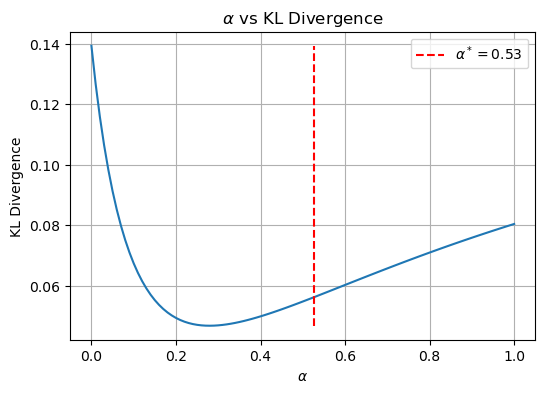

In [ ]:
alphas = np.arange(0, 1.01, 0.01)
kl_vals = []

for alpha in alphas:
    adj_dist = vh_with_homophily_adjustment(rds_df, graph_covariates, recruiter_map, alpha=alpha)
    kl = kl_divergence(adj_dist, pop_dist)
    kl_vals.append(kl)

true_best_alpha = np.argmin(kl_vals)
print(f"Optimal alpha: {alphas[true_best_alpha]:.2f} with KL divergence {kl_vals[true_best_alpha]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(alphas, kl_vals)
plt.xlabel("$\\alpha$")
plt.ylabel("KL Divergence")
plt.title("$\\alpha$ vs KL Divergence")
plt.vlines(x=found_alpha, ymin=min(kl_vals), ymax=max(kl_vals), colors='r', linestyles='dashed', label=f'$\\alpha^*={found_alpha:.2f}$')
plt.grid(True)
plt.legend()
plt.savefig("../img/single_trial_alpha_vs_kl.pdf")
plt.show()

## Distribution of Alpha Estimates vs. True Optimal Alpha

In [17]:
alpha_best_minus_found = []
kl_differences = []

for i in range(100):
    result = single_experiment(
        seed=i,
        num_blocks=7,
        total_nodes=120,
        p_in=0.5,
        p_out=0.02,
        num_opinions=4,
        opinion_correlation=0.90,
        RDS_num_seeds=2,
        RDS_sample_size=30,
        max_recruits=2
    )

    sample_dist = result["sample_dist"]
    vh_dist = result["vh_dist"]
    adj_dist = result["adj_dist"]
    pop_dist = result["pop_dist"]
    found_alpha = result["found_alpha"]
    rds_df = result["rds_df"]
    graph_covariates = result["graph_covariates"]
    recruiter_map = result["recruiter_map"]

    kl_using_found_alpha = kl_divergence(adj_dist, pop_dist)

    alphas = np.arange(0, 1.01, 0.01)
    kl_vals = []

    for alpha in alphas:
        adj_dist = vh_with_homophily_adjustment(rds_df, graph_covariates, recruiter_map, alpha=alpha)
        kl = kl_divergence(adj_dist, pop_dist)
        kl_vals.append(kl)
    
    best_kl = min(kl_vals)

    true_best_alpha = alphas[np.argmin(kl_vals)]
    alpha_best_minus_found.append(true_best_alpha - found_alpha)

    kl_difference = kl_vals[-1] - kl_using_found_alpha
    kl_differences.append(kl_difference)

AttributeError: module 'matplotlib.pyplot' has no attribute 'kdeplot'

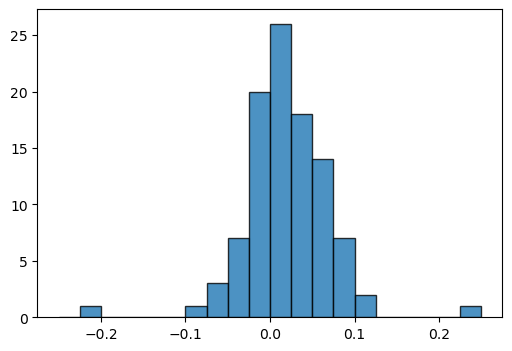

In [ ]:

bins = np.arange(-0.25, 0.275, 0.025)

mean_val = np.mean(kl_differences)
num_positive = sum(x > 0 for x in kl_differences)

plt.figure(figsize=(6, 4))

plt.hist(
    kl_differences,
    bins=bins,
    edgecolor='black',
    alpha=0.8
)


plt.xlabel("KL Divergence Difference")
plt.ylabel("Count")
plt.title("Distribution of KL Divergence Differences")

plt.text(
    0.98, 0.95,
    f"Mean = {mean_val:.3f}\n% > 0 = {num_positive/len(kl_differences):.0%}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.savefig("../img/kl_difference_histogram.pdf")
plt.show()

print(num_positive)
print(mean_val)